In [ ]:
import sys
!{sys.executable} -m pip install kaggle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c spaceship-titanic

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [ ]:
!unzip -o /content/spaceship-titanic.zip

Archive:  /content/spaceship-titanic.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv('train.csv')
df.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [ ]:
df = df.dropna()
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)


Shape: (6606, 14)

Missing values:
 PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64

Data types:
 PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object


In [ ]:
df =df.drop('Name',axis=1)

In [ ]:
df[['Deck', 'CabinNum', 'Side']] = df['Cabin'].str.split('/', expand=True)
df['CabinNum'] = df['CabinNum'].astype(int)
# df = pd.get_dummies(df, columns=['Deck'])
df['Deck'] = pd.to_numeric(df['Deck'], errors='coerce')

df['Side'] = df['Side'].map({'P':0, 'S':1})

KeyError: 'Cabin'

In [ ]:
encoder = LabelEncoder()
df = pd.get_dummies(df, columns=['HomePlanet'], drop_first=True)
df = pd.get_dummies(df, columns=['CryoSleep'], drop_first=True)
df = pd.get_dummies(df, columns=['Destination'], drop_first=True)
df['VIP'] = encoder.fit_transform(df['VIP'])

df['Transported'] = encoder.fit_transform(df['Transported'])
print(df)

KeyError: "None of [Index(['HomePlanet'], dtype='object')] are in the [columns]"

In [ ]:
df[['group_id', 'member_id']] = (
    df['PassengerId']
    .str.strip()
    .str.split('_', expand=True)
)

df['group_id'] = pd.to_numeric(df['group_id'], errors='coerce')
df['member_id'] = pd.to_numeric(df['member_id'], errors='coerce')

KeyError: 'PassengerId'

In [ ]:
df.drop(['Cabin','PassengerId'],axis=1,inplace=True)

KeyError: "['Cabin', 'PassengerId'] not found in axis"

In [ ]:
# from sklearn.preprocessing import StandardScaler
# df['Age_scaled'] = StandardScaler().fit_transform(df[['Age']])


In [ ]:
# df['Age_bin'] = pd.cut(df['Age'], bins=[0,12,18,30,50,80], labels=['Child','Teen','YoungAdult','Adult','Senior'])
# df = pd.get_dummies(df, columns=['Age_bin'],drop_first=True)

In [ ]:

df['TotalSpending'] = df[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)


In [ ]:
# Loop through all columns and print unique values + counts
for col in df.columns:
    print(f"\nColumn: {col}")
    # print("Unique values:", df[col].unique())
    print("Number of unique values:", df[col].nunique())
    print("Value counts:")
    print(df[col].value_counts().head(10))  # show top 10 for readability



Column: Age
Number of unique values: 80
Value counts:
Age
24.0    255
18.0    255
22.0    234
21.0    227
19.0    225
23.0    216
26.0    209
28.0    205
20.0    205
25.0    202
Name: count, dtype: int64

Column: VIP
Number of unique values: 2
Value counts:
VIP
0    6444
1     162
Name: count, dtype: int64

Column: RoomService
Number of unique values: 1093
Value counts:
RoomService
0.0     4318
1.0       93
2.0       60
3.0       43
4.0       35
9.0       22
8.0       20
5.0       19
14.0      17
6.0       16
Name: count, dtype: int64

Column: FoodCourt
Number of unique values: 1293
Value counts:
FoodCourt
0.0     4241
1.0       83
2.0       47
4.0       38
3.0       37
5.0       26
10.0      23
9.0       22
7.0       22
6.0       21
Name: count, dtype: int64

Column: ShoppingMall
Number of unique values: 984
Value counts:
ShoppingMall
0.0     4332
1.0      130
2.0       57
3.0       43
4.0       37
7.0       31
5.0       29
6.0       26
13.0      23
10.0      23
Name: count, dtype: i

In [ ]:
 print(df)


       Age  VIP  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  \
0     39.0    0          0.0        0.0           0.0     0.0     0.0   
1     24.0    0        109.0        9.0          25.0   549.0    44.0   
2     58.0    1         43.0     3576.0           0.0  6715.0    49.0   
3     33.0    0          0.0     1283.0         371.0  3329.0   193.0   
4     16.0    0        303.0       70.0         151.0   565.0     2.0   
...    ...  ...          ...        ...           ...     ...     ...   
8688  41.0    1          0.0     6819.0           0.0  1643.0    74.0   
8689  18.0    0          0.0        0.0           0.0     0.0     0.0   
8690  26.0    0          0.0        0.0        1872.0     1.0     0.0   
8691  32.0    0          0.0     1049.0           0.0   353.0  3235.0   
8692  44.0    0        126.0     4688.0           0.0     0.0    12.0   

      Transported  Deck  CabinNum  Side  HomePlanet_Europa  HomePlanet_Mars  \
0               0   NaN         0     0     

In [ ]:
df.dtypes

,0
Age,float64
VIP,int64
RoomService,float64
FoodCourt,float64
ShoppingMall,float64
Spa,float64
VRDeck,float64
Transported,int64
Deck,float64
CabinNum,int64


In [ ]:
df.head(20)

,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side,HomePlanet_Europa,HomePlanet_Mars,CryoSleep_True,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,group_id,member_id,TotalSpending
0,39.0,0,0.0,0.0,0.0,0.0,0.0,0,NaN,0,0,True,False,False,False,True,1,1,0.0
1,24.0,0,109.0,9.0,25.0,549.0,44.0,1,NaN,0,1,False,False,False,False,True,2,1,736.0
2,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,NaN,0,1,True,False,False,False,True,3,1,10383.0
3,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,NaN,0,1,True,False,False,False,True,3,2,5176.0
4,16.0,0,303.0,70.0,151.0,565.0,2.0,1,NaN,1,1,False,False,False,False,True,4,1,1091.0
5,44.0,0,0.0,483.0,0.0,291.0,0.0,1,NaN,0,0,False,False,False,True,False,5,1,774.0
6,26.0,0,42.0,1539.0,3.0,0.0,0.0,1,NaN,2,1,False,False,False,False,True,6,1,1584.0
8,35.0,0,0.0,785.0,17.0,216.0,0.0,1,NaN,3,1,False,False,False,False,True,7,1,1018.0
9,14.0,0,0.0,0.0,0.0,0.0,0.0,1,NaN,1,0,True,False,True,False,False,8,1,0.0
11,45.0,0,39.0,7295.0,589.0,110.0,124.0,1,NaN,1,0,True,False,False,False,False,8,3,8157.0


In [ ]:
df['Deck_Spend'] = df['VRDeck'] * df['HomePlanet_Europa']

In [ ]:
df.drop(['Deck_Spend','TotalSpending'],axis=1,inplace=True)

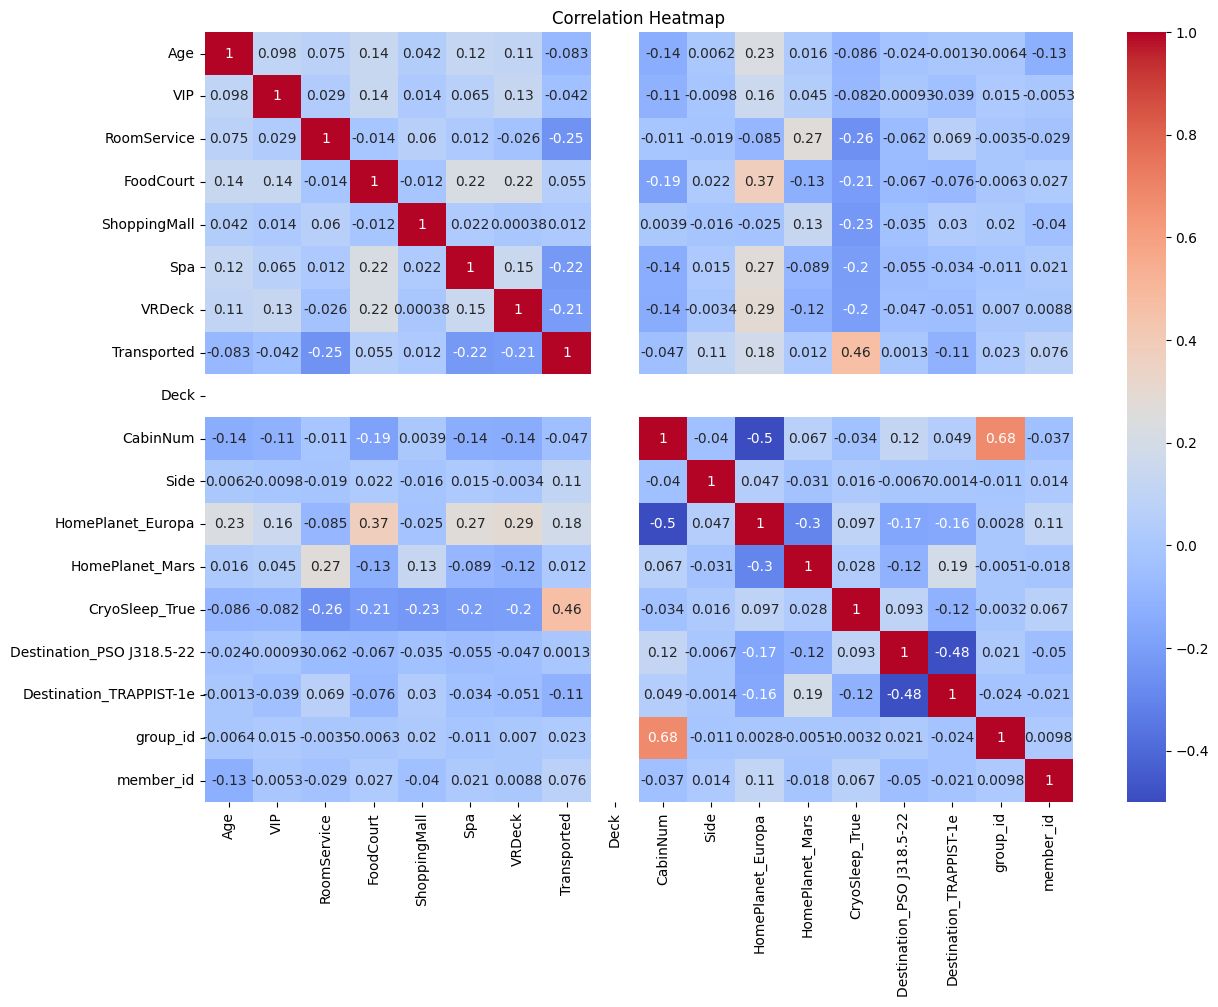

In [ ]:
corr = df.corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

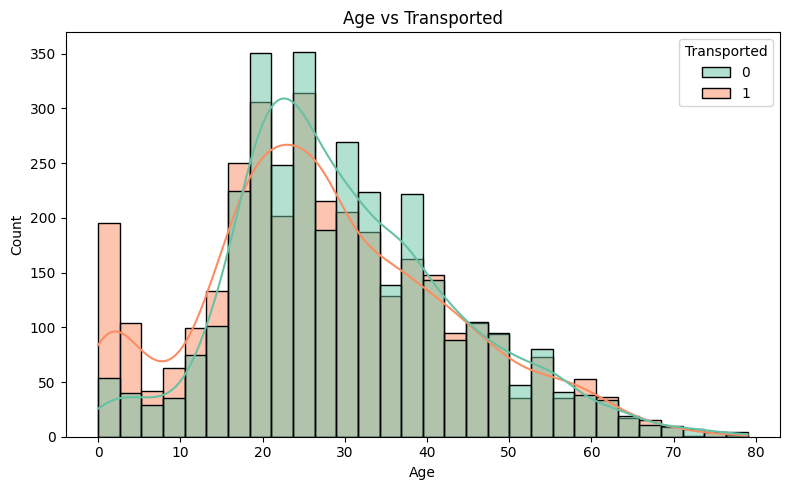

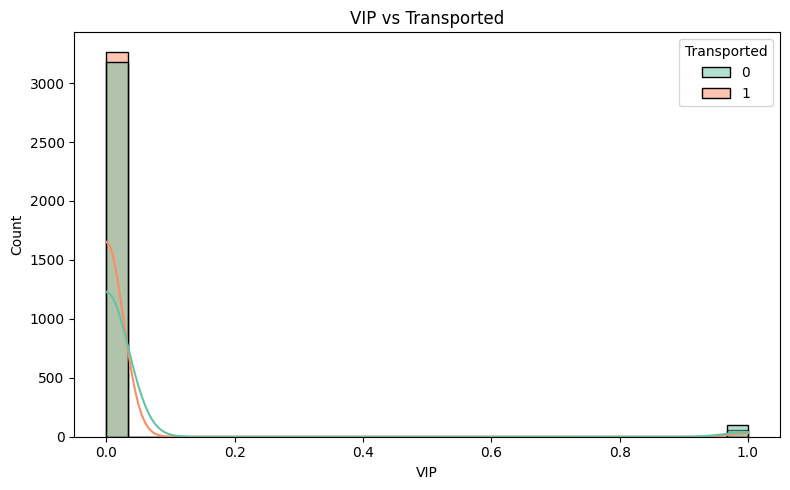

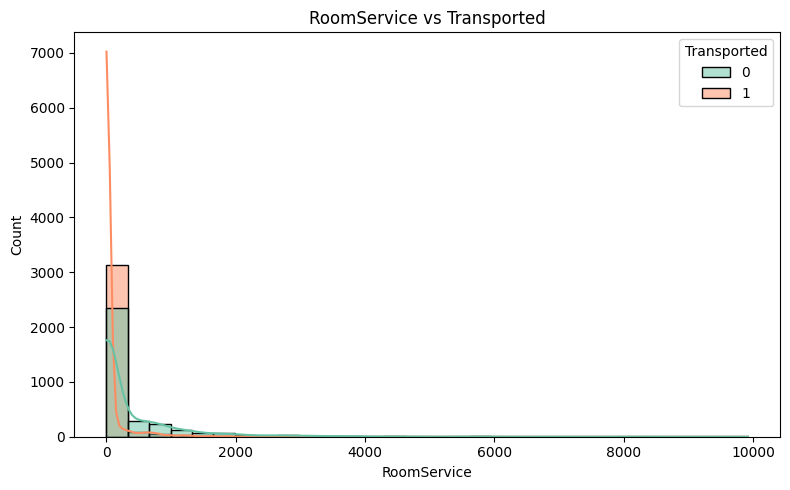

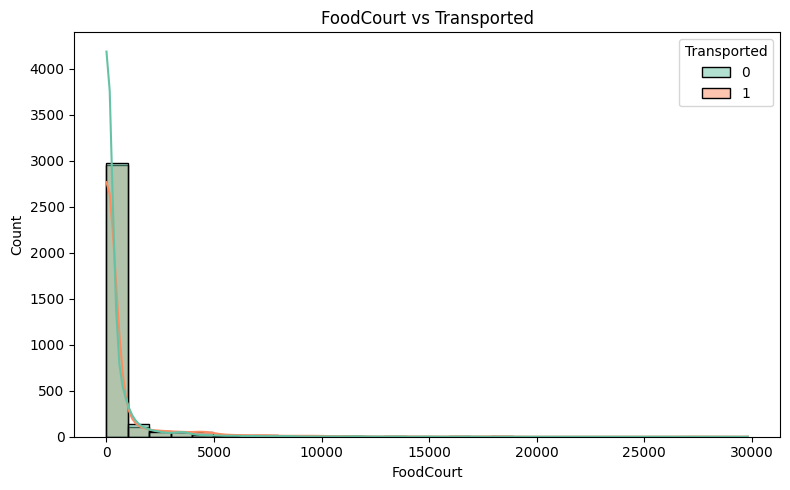

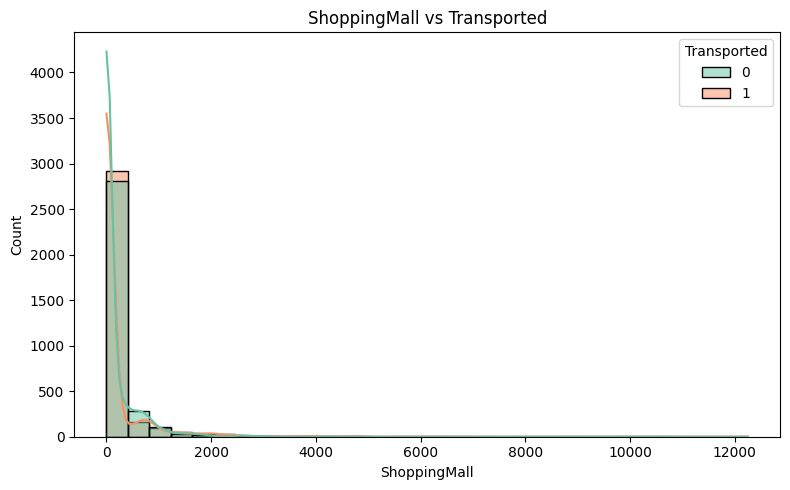

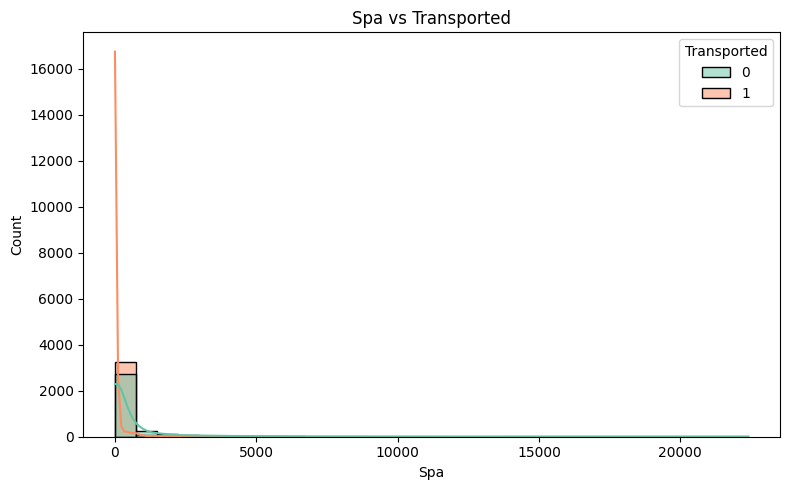

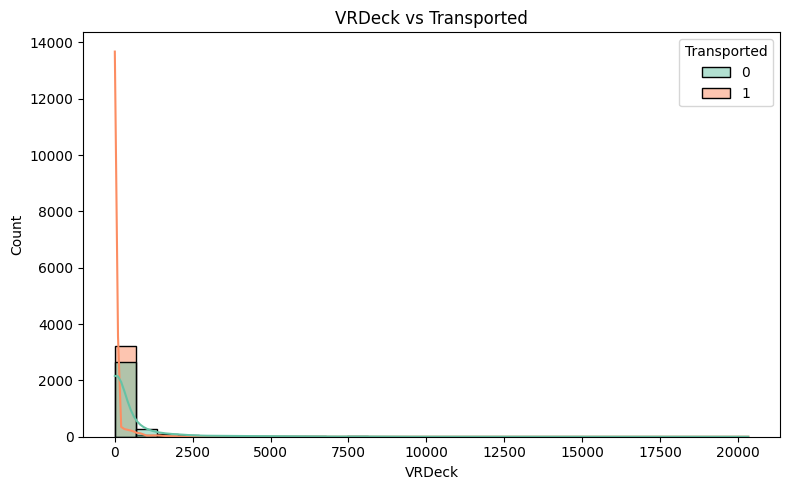

ValueError: `dataset` input should have multiple elements.

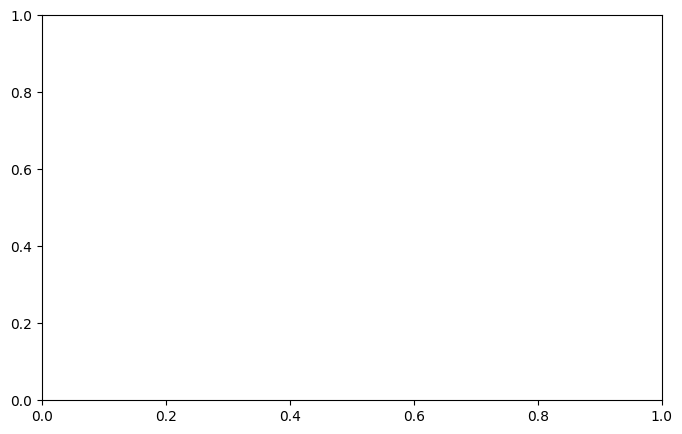

In [ ]:
target = "Transported"

for col in df.columns:
    if col == target:
        continue  # skip the target itself

    plt.figure(figsize=(8,5))

    if df[col].dtype in ['int64','float64']:
        # Numeric feature → distribution by Transported
        sns.histplot(data=df, x=col, hue=target, bins=30, kde=True, palette="Set2")
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel("Count")

    else:
        # Categorical feature → countplot by Transported
        sns.countplot(data=df, x=col, hue=target, palette="Set2")
        plt.title(f"{col} vs {target},fuck")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


In [ ]:
df.corr()['HomePlanet_Europa'].sort_values(ascending=False)


In [ ]:
from sklearn.model_selection import train_test_split
x= df.drop(['Transported','CabinNum',],axis=1)
# x= df.drop(['Transported','TotalSpending','Age','Age_scaled','HomePlanet_Europa'],axis=1)

y= df['Transported']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(penalty='l2', solver='liblinear')
model.fit(x_train, y_train)

print("Model training complete. Here are the first 5 predictions on the test set:")
predictions = model.predict(x_test)
print(predictions[:5])

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# from sklearn.linear_model import LogisticRegression

# model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter
# model.fit(x_train, y_train)

# print("Model training complete. Here are the first 5 predictions on the test set:")
# predictions = model.predict(x_test)
# print(predictions[:5])

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7987897125567323


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

model_scaled = LogisticRegression(penalty='l1', solver='liblinear')
model_scaled.fit(x_train_scaled, y_train)

print("Model training complete with scaled data. Here are the first 5 predictions:")
predictions_scaled = model_scaled.predict(x_test_scaled)
print(predictions_scaled[:5])

Model training complete with scaled data. Here are the first 5 predictions:
[1 1 1 1 0]


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = model_scaled.predict(x_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7957639939485628


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

params = [
    {
        'model__penalty': ['l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs']
    },
    {
        'model__penalty': ['l1'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear']
    }
]

grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(x_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__C': 10, 'model__penalty': 'l1', 'model__solver': 'liblinear'}
0.7956111493363149


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Scale the entire feature dataset for cross-validation
x_scaled = scaler.fit_transform(x)

# Define the cross-validation strategy
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define the model (using the same parameters as before)
cv_model = LogisticRegression(penalty='l2', random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(cv_model, x_scaled, y, cv=kf, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation scores: [0.79425113 0.7986374  0.79409538 0.78803936 0.79712339]
Mean cross-validation accuracy: 0.7944
Standard deviation of cross-validation accuracy: 0.0036


In [ ]:
test_df = pd.read_csv('test.csv')
submission_passenger_ids = test_df['PassengerId']

# --- Imputation values from the preprocessed training DataFrame (df) ---
# For numerical features, use median
median_age = df['Age'].median()
median_roomservice = df['RoomService'].median()
median_foodcourt = df['FoodCourt'].median()
median_shoppingmall = df['ShoppingMall'].median()
median_spa = df['Spa'].median()
median_vrdeck = df['VRDeck'].median()
median_cabinnum = df['CabinNum'].median()

# For categorical features, use mode
mode_homeplanet = df['HomePlanet_Europa'].mode()[0] # HomePlanet was one-hot encoded in 'df'
mode_cryosleep = df['CryoSleep'].mode()[0]
mode_destination = df['Destination_TRAPPIST-1e'].mode()[0] # Destination was one-hot encoded in 'df'
mode_vip = df['VIP'].mode()[0]
mode_deck = df['Deck'].mode()[0]
mode_side = df['Side'].mode()[0]

# --- Create and fit LabelEncoders for CryoSleep and VIP from the training df ---
le_cryosleep = LabelEncoder()
le_vip = LabelEncoder()
le_cryosleep.fit(df['CryoSleep'])
le_vip.fit(df['VIP'])

def preprocess_test_data(df_input):
    temp_df = df_input.copy()

    # Drop Name
    temp_df.drop('Name', axis=1, inplace=True, errors='ignore')

    # Impute numerical features
    temp_df['Age'] = temp_df['Age'].fillna(median_age)
    temp_df['RoomService'] = temp_df['RoomService'].fillna(median_roomservice)
    temp_df['FoodCourt'] = temp_df['FoodCourt'].fillna(median_foodcourt)
    temp_df['ShoppingMall'] = temp_df['ShoppingMall'].fillna(median_shoppingmall)
    temp_df['Spa'] = temp_df['Spa'].fillna(median_spa)
    temp_df['VRDeck'] = temp_df['VRDeck'].fillna(median_vrdeck)

    # Impute categorical features before encoding for consistency
    # For HomePlanet and Destination, get_dummies will handle NaNs if not filled, but for consistency let's fill
    temp_df['HomePlanet'] = temp_df['HomePlanet'].fillna(mode_homeplanet)
    temp_df['Destination'] = temp_df['Destination'].fillna(mode_destination)
    temp_df['CryoSleep'] = temp_df['CryoSleep'].fillna(mode_cryosleep)
    temp_df['VIP'] = temp_df['VIP'].fillna(mode_vip)

    # Process Cabin
    temp_df['Cabin'] = temp_df['Cabin'].fillna('Z/9999/P') # Impute placeholder for splitting
    temp_df[['Deck', 'CabinNum', 'Side']] = temp_df['Cabin'].str.split('/', expand=True)
    temp_df['CabinNum'] = pd.to_numeric(temp_df['CabinNum'], errors='coerce')
    temp_df['CabinNum'] = temp_df['CabinNum'].fillna(median_cabinnum)
    temp_df['CabinNum'] = temp_df['CabinNum'].astype(int)
    temp_df['Deck'] = temp_df['Deck'].astype('category').cat.codes
    temp_df['Side'] = temp_df['Side'].map({'P':0, 'S':1})
    temp_df['Side'] = temp_df['Side'].fillna(mode_side) # Impute any NaNs in Side after map

    # Encode CryoSleep and VIP using the encoders fitted on training data
    temp_df['CryoSleep'] = le_cryosleep.transform(temp_df['CryoSleep'])
    temp_df['VIP'] = le_vip.transform(temp_df['VIP'])

    # One-hot encode HomePlanet and Destination
    temp_df = pd.get_dummies(temp_df, columns=['HomePlanet'], drop_first=True)
    temp_df = pd.get_dummies(temp_df, columns=['Destination'], drop_first=True)

    # Create 'group_id' and 'member_id'
    temp_df[['group_id', 'member_id']] = temp_df['PassengerId'].str.strip().str.split('_', expand=True)
    temp_df['group_id'] = pd.to_numeric(temp_df['group_id'], errors='coerce')
    temp_df['member_id'] = pd.to_numeric(temp_df['member_id'], errors='coerce')
    # Impute potential NaNs in group_id and member_id (e.g., if PassengerId format is bad)
    temp_df['group_id'] = temp_df['group_id'].fillna(temp_df['group_id'].median())
    temp_df['member_id'] = temp_df['member_id'].fillna(temp_df['member_id'].median())
    temp_df['group_id'] = temp_df['group_id'].astype(int)
    temp_df['member_id'] = temp_df['member_id'].astype(int)


    # Create Age_bin and one-hot encode
    temp_df['Age_bin'] = pd.cut(temp_df['Age'], bins=[0,12,18,30,50,80], labels=['Child','Teen','YoungAdult','Adult','Senior'])
    temp_df = pd.get_dummies(temp_df, columns=['Age_bin'], drop_first=True)

    # Create TotalSpending
    temp_df['TotalSpending'] = temp_df[['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']].sum(axis=1)

    # Create Deck_Spend
    if 'HomePlanet_Europa' not in temp_df.columns:
        temp_df['HomePlanet_Europa'] = False # If no Europa in test, set to False
    temp_df['Deck_Spend'] = temp_df['VRDeck'] * temp_df['HomePlanet_Europa']

    # Drop original 'Cabin' and 'PassengerId'
    temp_df.drop(['Cabin', 'PassengerId'], axis=1, inplace=True, errors='ignore')

    return temp_df

# Preprocess the test data
test_df_processed = preprocess_test_data(test_df)

# Align test_df_processed columns with x_train columns
# x is the training feature DataFrame from the kernel state
final_x_cols = x.columns.tolist()

# Add missing columns (if any) with 0
missing_cols = set(final_x_cols) - set(test_df_processed.columns)
for col in missing_cols:
    test_df_processed[col] = 0

# Drop extra columns (if any)
extra_cols = set(test_df_processed.columns) - set(final_x_cols)
test_df_processed.drop(columns=list(extra_cols), inplace=True)

# Reorder columns to match the training data
test_df_final = test_df_processed[final_x_cols]

# Make predictions using the best estimator from GridSearchCV
# The grid.best_estimator_ is a pipeline, so it handles scaling internally.
predictions = grid.best_estimator_.predict(test_df_final)

# Create submission DataFrame
submission = pd.DataFrame({
    'PassengerId': submission_passenger_ids,
    'Transported': predictions.astype(bool) # Convert to boolean as per original 'Transported' type
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully.")
print(submission.head())

Submission file 'submission.csv' created successfully.
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01         True
